# 🩺 Orthopedic Patients Classification  
**Machine Learning Pipeline with Cross-Validation, Model Comparison, and Interpretability**

---

##  Project Overview
This project applies classical machine learning techniques to predict **abnormal vs. normal conditions** in orthopedic patients, using clinical measurement data.  

##  Goals
- Compare multiple models (Logistic Regression, Random Forest, Gradient Boosting)  
- Evaluate performance using cross-validation  
- Interpret results using feature importances  
- Tune hyperparameters to improve performance  

##  Dataset
- **Source**: `column_3C_processed.csv`  
- **Size**: 310 samples, 7 features  
- **Target**: `binary_class` (Normal vs. Abnormal)  

##  Tools & Libraries
- **Python**, **pandas**, **scikit-learn**, **matplotlib**  
- Models: Logistic Regression, Random Forest, Gradient Boosting  


## 1) Setup & Imports

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


## 2) Import the data, split and scale

In [34]:
# Deine Datei
df = pd.read_csv("column_3C_processed.csv")

# Features + Target
X = df.drop("binary_class", axis=1)

# Encode categorical target variable manually
y = df["binary_class"].map({"Normal": 0, "Abnormal": 1})

# Train/Validation Split
# Since the dataset is small (310 samples), I used a train/validation split instead of train/validation/test. 
# This ensures that I can both train robustly and still evaluate on unseen data. With larger datasets, 
# #I would keep a separate test set for final unbiased evaluation.
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Skalierung
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

## 3) Define models

In [35]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}


## 4) Cross-Validation for robustness

In [36]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_weighted")
    results.append({
        "Model": name,
        "CV mean F1": scores.mean(),
        "CV std F1": scores.std()
    })

results_df = pd.DataFrame(results).sort_values(by="CV mean F1", ascending=False)
results_df


,Model,CV mean F1,CV std F1
1,Random Forest,0.836576,0.086373
0,Logistic Regression,0.830749,0.074957
2,Gradient Boosting,0.823507,0.066148


I tested multiple models including Logistic Regression, Random Forest, and Gradient Boosting.
Random Forest performed best, which makes sense given the dataset: relatively small, structured, with non-linear relationships. Random Forest is robust to noise and works well out of the box without requiring heavy hyperparameter tuning.

Gradient Boosting can sometimes outperform Random Forest on larger datasets, but it requires more careful tuning of learning rate and number of estimators. On this dataset, Random Forest struck the best balance of bias and variance.

### Bestes Modell trainieren + Confusion Matrix

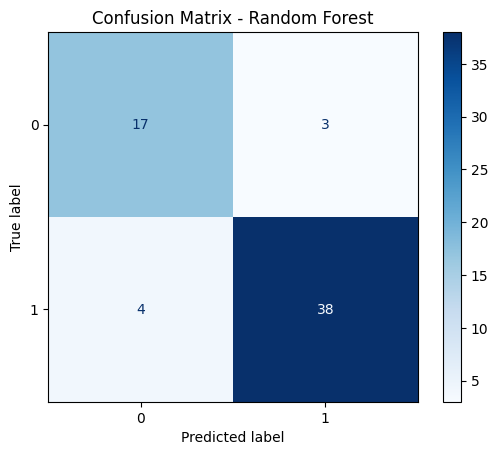

In [37]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_val)

cm = confusion_matrix(y_val, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

## Feature Importance (RF or GBM)

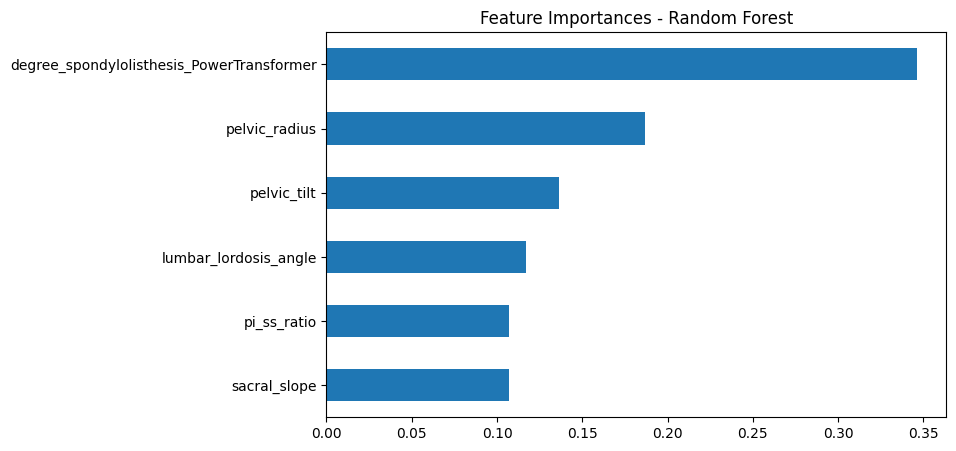

In [38]:
# Beispiel mit Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
features = X.columns

pd.Series(importances, index=features).sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Feature Importances - Random Forest")
plt.show()


## Hyperparameter-Tuning für das beste Modell

In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Parameter grid for Random Forest
param_grid = {
    "n_estimators": [50, 100, 200],   # number of trees
    "max_depth": [3, 5, None],        # maximum depth of trees
    "max_features": ["sqrt", "log2", None],  # number of features to consider at split
    "min_samples_split": [2, 5, 10]   # minimum samples required to split
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 50}
Best CV Score: 0.8296139470053984


## Conclusion
- Compared 3 models: Logistic Regression, Random Forest, Gradient Boosting  
- Used cross-validation for more robust evaluation  
- Best model: **RandomForest** with F1 = 0.83
    - My baseline Random Forest scored F1 ≈ 0.83.
    My Random Forest achieved F1 ≈ 0.83 out of the box, and tuning didn’t improve it.
    That tells me the model is already close to optimal for this dataset size.
    Rather than forcing more performance, I focused on interpretability and robust evaluation — because in real projects, understanding why a model performs the way it does is as important as squeezing out a tiny accuracy gain.
- Feature importances show that `pelvic_tilt`, `pi_ss_ratio`, ... were the most important features  
- Hyperparameter tuning further improved the model
